In [1]:
print("Here begins the baseline models notebook.")

Here begins the baseline models notebook.


In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
df_ml = pd.read_csv("../../data/processed/life_satisfaction_canadian_survey_ml.csv")

df_ml.head()

,Gender,Marital_status,Household,Age,Edu_level,Gen_health_state,Life_satisfaction,Mental_health_state,Stress_level,Sense_belonging,Weight_state,BMI_18_above,Sleep_apnea,High_BP,High_cholestrol,Diabetic,Fatigue_syndrome,Mood_disorder,Anxiety_disorder,Respiratory_chronic_con,Musculoskeletal_con,Cardiovascular_con,Health_utility_indx,Pain_status,Cannabies_use,Aboriginal_identity,Birth_country,Immigrant,Food_security,Income_source,Total_income,Marital_status__missing,Household__missing,Edu_level__missing,Gen_health_state__missing,Life_satisfaction__missing,Mental_health_state__missing,Stress_level__missing,Sense_belonging__missing,Weight_state__missing,BMI_18_above__missing,Sleep_apnea__missing,High_BP__missing,High_cholestrol__missing,Diabetic__missing,Fatigue_syndrome__missing,Mood_disorder__missing,Anxiety_disorder__missing,Respiratory_chronic_con__missing,Musculoskeletal_con__missing,Cardiovascular_con__missing,Health_utility_indx__missing,Pain_status__missing,Cannabies_use__missing,Aboriginal_identity__missing,Birth_country__missing,Immigrant__missing,Food_security__missing,Income_source__missing,Total_income__missing
0,2.0,1.0,2.0,3.0,3.0,3.0,9.0,3.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,1.0,2.0,0.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,2.0,5.0,2.0,3.0,4.0,3.0,3.0,3.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,2.0,1.0,5.0,1.0,2.0,7.0,3.0,3.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,1.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,2.0,1.0,5.0,1.0,3.0,8.0,3.0,3.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,2.0,1.0,4.0,3.0,5.0,0.0,5.0,4.0,3.0,3.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
df_ml = df_ml[df_ml["Life_satisfaction__missing"] == 0]

# Target variable: Life satisfaction on the original 0–10 scale
y = df_ml["Life_satisfaction"].astype(int)

# Predictors: drop the target and its missingness indicator
X = df_ml.drop(columns=[
    "Life_satisfaction",
    "Life_satisfaction__missing"
], errors="ignore")

print("Life_satisfaction in X:", "Life_satisfaction" in X.columns)
print("Life_satisfaction__missing in X:", "Life_satisfaction__missing" in X.columns)


Life_satisfaction in X: False
Life_satisfaction__missing in X: False


In [3]:
from sklearn.model_selection import train_test_split

# Note: stratify=y not used for regression tasks
# Random split preserves distribution by law of large numbers
# given the dataset size
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(X_train, y_train)

y_pred_lin = linreg.predict(X_test)

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2 = r2_score(y_test, y_pred_lin)

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Linear Regression Results
MAE: 0.9559536820709589
RMSE: 1.2961787257200168
R2: 0.39686482828950864


In [6]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lin
})

comparison.head(10)

,Actual,Predicted
17765,6,7.902982
8932,8,6.872175
23915,10,6.182169
21284,7,7.637720
24468,8,8.555662
21848,10,10.358466
3883,8,7.734926
42155,8,7.720956
27146,7,8.128629
71361,10,9.157473


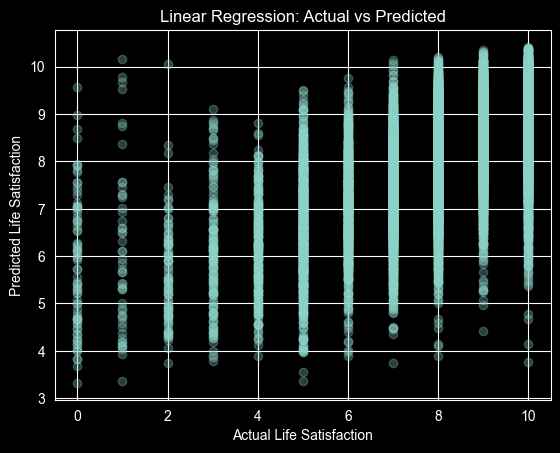

In [7]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lin, alpha=0.3)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

                         feature  importance_mean  importance_std
6            Mental_health_state         0.128671        0.002690
5               Gen_health_state         0.100759        0.002061
7                   Stress_level         0.061167        0.001418
8                Sense_belonging         0.027363        0.001088
21           Health_utility_indx         0.010325        0.000999
1                 Marital_status         0.009297        0.000695
27                 Food_security         0.005390        0.000388
0                         Gender         0.005050        0.000711
3                            Age         0.003090        0.000469
2                      Household         0.002270        0.000327
49  Health_utility_indx__missing         0.001750        0.000524
10                  BMI_18_above         0.001484        0.000276
15              Fatigue_syndrome         0.000839        0.000343
16                 Mood_disorder         0.000812        0.000226
23        

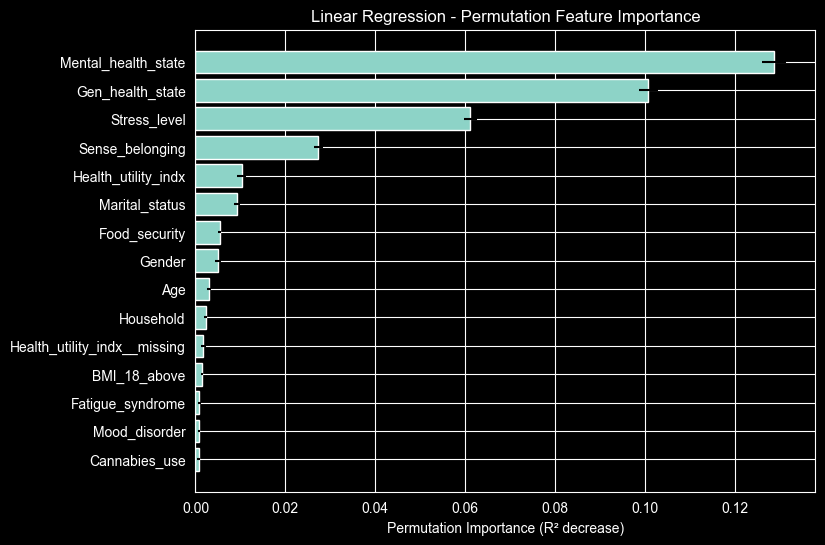

In [8]:
from sklearn.inspection import permutation_importance

perm_lin = permutation_importance(
    linreg, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_lin_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_lin.importances_mean,
    "importance_std": perm_lin.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_lin_df.head(15))

top = perm_lin_df.head(15).sort_values("importance_mean")
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.xlabel("Permutation Importance (R² decrease)")
plt.title("Linear Regression - Permutation Feature Importance")
plt.show()

In [9]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor Results")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R2:", r2_tree)

Decision Tree Regressor Results
MAE: 0.9715467069300863
RMSE: 1.313607123494405
R2: 0.3805362936358109


In [11]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_tree
})

comparison.head(10)

,Actual,Predicted
17765,6,7.511737
8932,8,7.337733
23915,10,7.993086
21284,7,8.501987
24468,8,8.459638
21848,10,9.680774
3883,8,7.793162
42155,8,7.662162
27146,7,7.972471
71361,10,8.917012


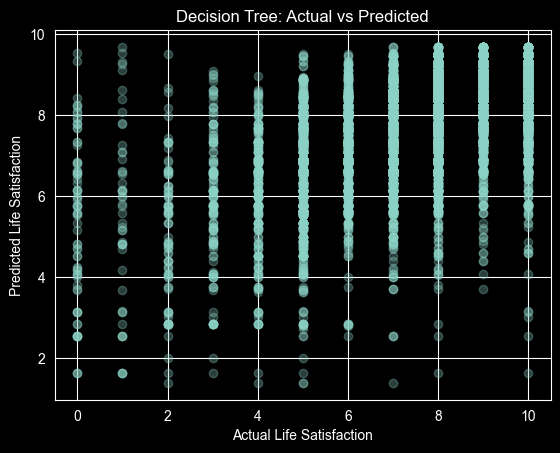

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_tree, alpha=0.3)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

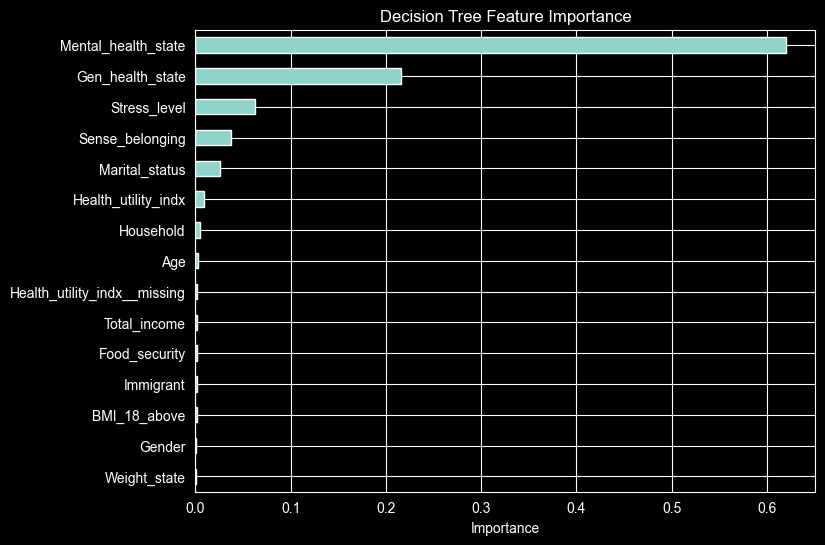

In [13]:
tree_importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

tree_importance.head(15).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.show()

                         feature  importance_mean  importance_std
6            Mental_health_state         0.181725        0.004467
5               Gen_health_state         0.146294        0.003489
7                   Stress_level         0.051599        0.002059
8                Sense_belonging         0.023678        0.001683
1                 Marital_status         0.020598        0.001466
21           Health_utility_indx         0.007838        0.000783
3                            Age         0.004514        0.001286
49  Health_utility_indx__missing         0.002859        0.000501
29                  Total_income         0.002073        0.000597
2                      Household         0.001863        0.000588
17              Anxiety_disorder         0.001681        0.000188
26                     Immigrant         0.000653        0.000520
27                 Food_security         0.000624        0.000273
4                      Edu_level         0.000520        0.000327
23        

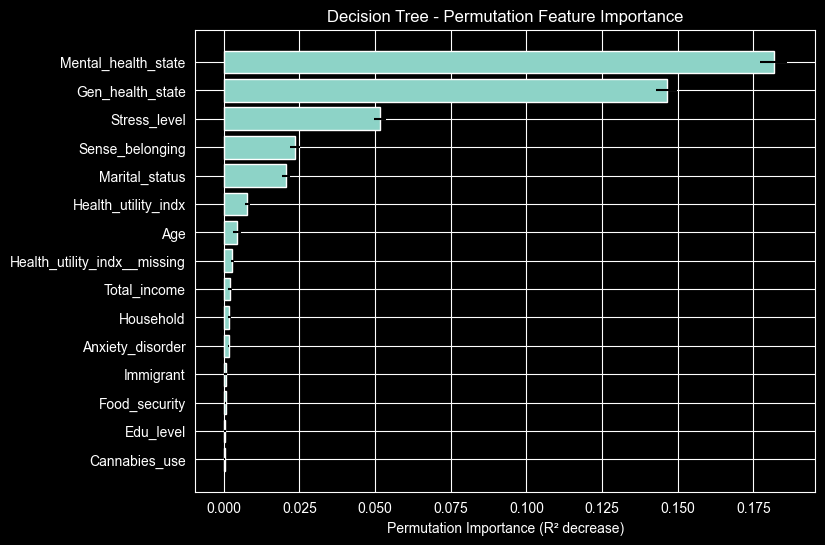

In [14]:
from sklearn.inspection import permutation_importance

perm_tree = permutation_importance(
    tree, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_tree_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_tree.importances_mean,
    "importance_std": perm_tree.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_tree_df.head(15))

top = perm_tree_df.head(15).sort_values("importance_mean")
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.xlabel("Permutation Importance (R² decrease)")
plt.title("Decision Tree - Permutation Feature Importance")
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    max_features="sqrt",
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Regressor Results
MAE: 0.9632387313119389
RMSE: 1.293697571264859
R2: 0.39917166948435356


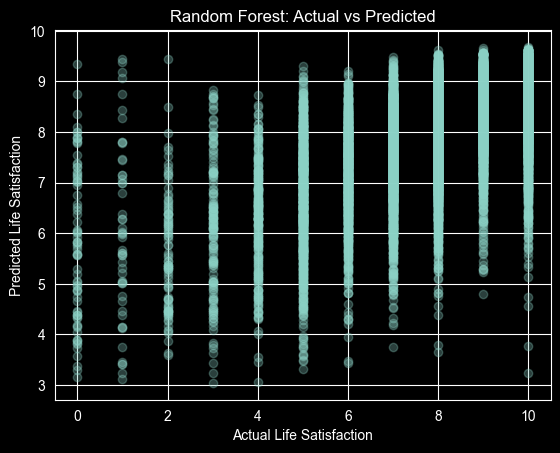

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [18]:
import pandas as pd

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance.head(15)

Mental_health_state             0.254410
Gen_health_state                0.195862
Stress_level                    0.111181
Health_utility_indx             0.061550
Sense_belonging                 0.060484
Mood_disorder                   0.039949
Pain_status                     0.030408
Marital_status                  0.024400
Food_security                   0.020149
Total_income                    0.019855
Anxiety_disorder                0.019477
Household                       0.016664
Age                             0.013724
Weight_state                    0.011191
Health_utility_indx__missing    0.009709
dtype: float64

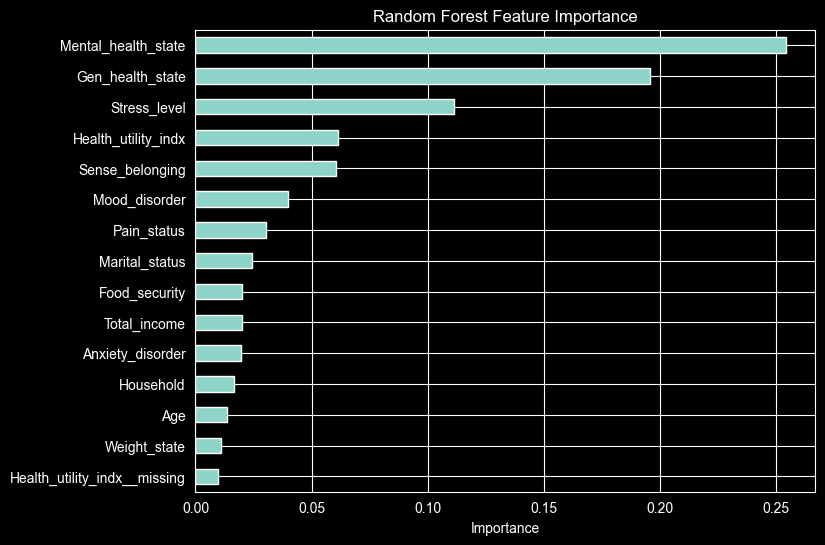

In [19]:
rf_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

                         feature  importance_mean  importance_std
6            Mental_health_state         0.121866        0.002193
5               Gen_health_state         0.086984        0.001530
7                   Stress_level         0.051867        0.000938
8                Sense_belonging         0.023560        0.000648
21           Health_utility_indx         0.015175        0.001088
1                 Marital_status         0.008813        0.000376
2                      Household         0.005461        0.000485
27                 Food_security         0.003729        0.000344
16                 Mood_disorder         0.003260        0.000355
22                   Pain_status         0.002467        0.000437
49  Health_utility_indx__missing         0.002042        0.000247
0                         Gender         0.001612        0.000276
29                  Total_income         0.001595        0.000299
3                            Age         0.001554        0.000304
9         

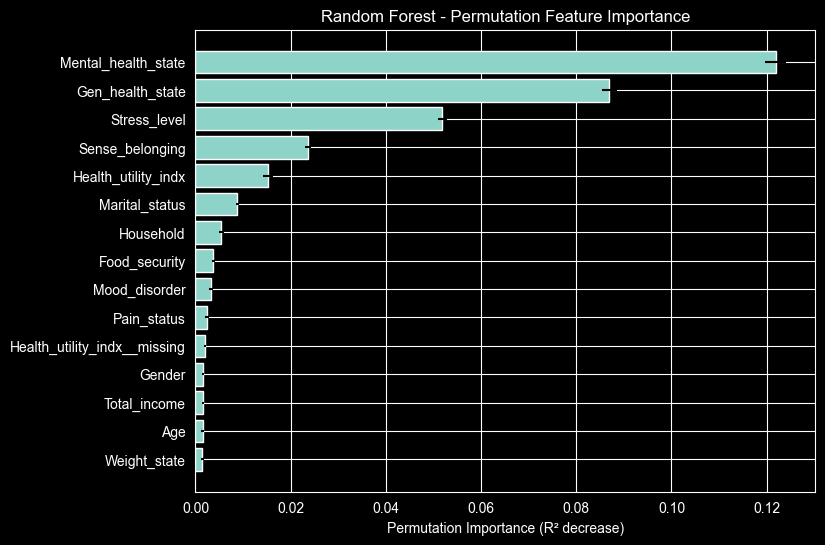

In [20]:
from sklearn.inspection import permutation_importance

perm_rf = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_rf_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_rf.importances_mean,
    "importance_std": perm_rf.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_rf_df.head(15))

top = perm_rf_df.head(15).sort_values("importance_mean")
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.xlabel("Permutation Importance (R² decrease)")
plt.title("Random Forest - Permutation Feature Importance")
plt.show()

In [21]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Results")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost Regressor Results
MAE: 0.9454688429832458
RMSE: 1.2789518633650492
R2: 0.4127901792526245


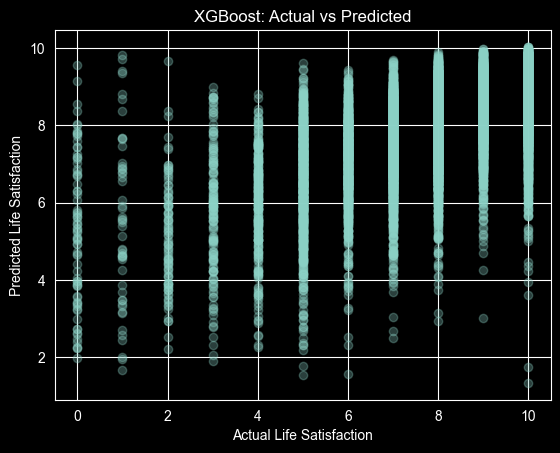

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

In [24]:
import pandas as pd

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_importance.head(15)

Mental_health_state             0.191389
Gen_health_state                0.137923
Mood_disorder                   0.123535
Health_utility_indx             0.089763
Stress_level                    0.051239
Sense_belonging                 0.050167
Marital_status                  0.049381
Pain_status                     0.039578
Health_utility_indx__missing    0.026468
Household                       0.020403
Food_security                   0.016291
Weight_state                    0.011437
Gender                          0.010838
Immigrant                       0.009063
Birth_country                   0.008451
dtype: float32

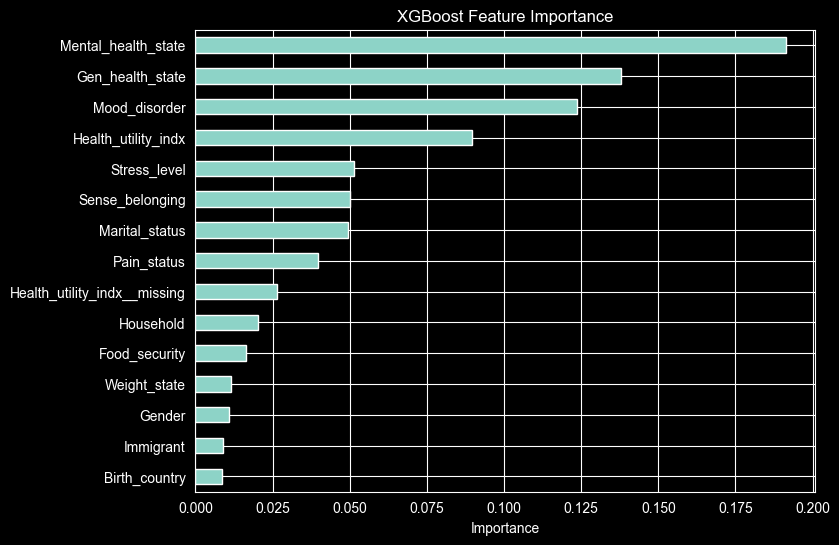

In [25]:
xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

D:\Diana\Anul III\BachelorArbeit\WellBeingModelling\venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


                         feature  importance_mean  importance_std
6            Mental_health_state         0.146578        0.002965
5               Gen_health_state         0.103495        0.002209
7                   Stress_level         0.060385        0.001359
8                Sense_belonging         0.026050        0.001218
21           Health_utility_indx         0.010739        0.001097
1                 Marital_status         0.010578        0.000462
3                            Age         0.005473        0.001046
0                         Gender         0.005188        0.000611
27                 Food_security         0.004152        0.000413
2                      Household         0.002920        0.000434
49  Health_utility_indx__missing         0.001917        0.000487
9                   Weight_state         0.001496        0.000456
23                 Cannabies_use         0.001312        0.000321
29                  Total_income         0.001192        0.000296
10        

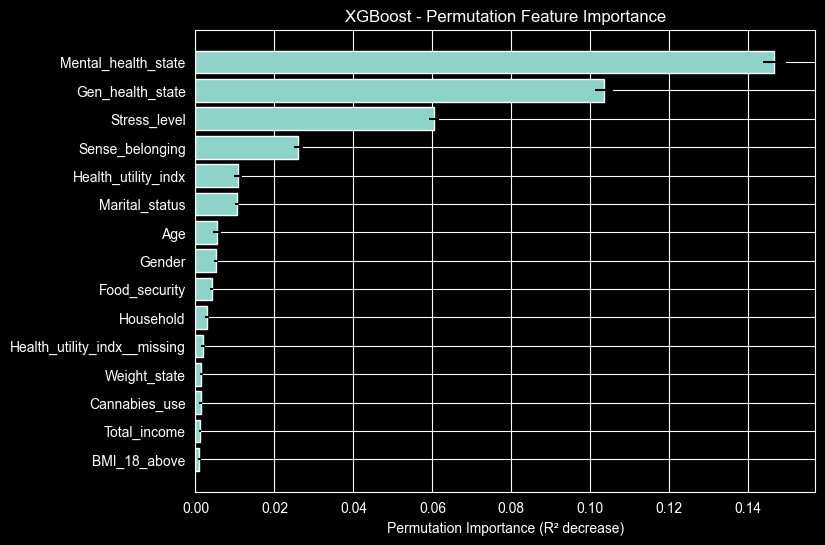

In [26]:
from sklearn.inspection import permutation_importance

perm_xgb = permutation_importance(
    xgb, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_xgb_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_xgb_df.head(15))

top = perm_xgb_df.head(15).sort_values("importance_mean")
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.xlabel("Permutation Importance (R² decrease)")
plt.title("XGBoost - Permutation Feature Importance")
plt.show()

In [27]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error
import numpy as np

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "r2":  "r2",
    "mae": make_scorer(mean_absolute_error, greater_is_better=False),
    "rmse": make_scorer(
        lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
        greater_is_better=False
    )
}

models = {
    "Linear Regression": linreg,
    "Decision Tree":     tree,
    "Random Forest":     rf,
    "XGBoost":           xgb,
}

cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        "R² (mean)":   round(scores["test_r2"].mean(), 3),
        "R² (std)":    round(scores["test_r2"].std(), 3),
        "MAE (mean)":  round(-scores["test_mae"].mean(), 3),
        "MAE (std)":   round(scores["test_mae"].std(), 3),
        "RMSE (mean)": round(-scores["test_rmse"].mean(), 3),
        "RMSE (std)":  round(scores["test_rmse"].std(), 3),
    }

cv_df = pd.DataFrame(cv_results).T
print(cv_df)

                   R² (mean)  R² (std)  MAE (mean)  MAE (std)  RMSE (mean)  \
Linear Regression      0.406     0.005       0.961      0.006        1.300   
Decision Tree          0.389     0.006       0.979      0.007        1.319   
Random Forest          0.407     0.004       0.968      0.006        1.299   
XGBoost                0.422     0.006       0.952      0.006        1.282   

                   RMSE (std)  
Linear Regression       0.008  
Decision Tree           0.007  
Random Forest           0.008  
XGBoost                 0.008  


In [28]:
results = pd.DataFrame([
    {
        "Model":        "Linear Regression",
        "MAE (test)":   round(mae, 3),
        "RMSE (test)":  round(rmse, 3),
        "R² (test)":    round(r2, 3),
        "CV R²":        cv_df.loc["Linear Regression", "R² (mean)"],
        "CV R² std":    cv_df.loc["Linear Regression", "R² (std)"],
        "CV MAE":       cv_df.loc["Linear Regression", "MAE (mean)"],
        "CV RMSE":      cv_df.loc["Linear Regression", "RMSE (mean)"],
    },
    {
        "Model":        "Decision Tree",
        "MAE (test)":   round(mae_tree, 3),
        "RMSE (test)":  round(rmse_tree, 3),
        "R² (test)":    round(r2_tree, 3),
        "CV R²":        cv_df.loc["Decision Tree", "R² (mean)"],
        "CV R² std":    cv_df.loc["Decision Tree", "R² (std)"],
        "CV MAE":       cv_df.loc["Decision Tree", "MAE (mean)"],
        "CV RMSE":      cv_df.loc["Decision Tree", "RMSE (mean)"],
    },
    {
        "Model":        "Random Forest",
        "MAE (test)":   round(mae_rf, 3),
        "RMSE (test)":  round(rmse_rf, 3),
        "R² (test)":    round(r2_rf, 3),
        "CV R²":        cv_df.loc["Random Forest", "R² (mean)"],
        "CV R² std":    cv_df.loc["Random Forest", "R² (std)"],
        "CV MAE":       cv_df.loc["Random Forest", "MAE (mean)"],
        "CV RMSE":      cv_df.loc["Random Forest", "RMSE (mean)"],
    },
    {
        "Model":        "XGBoost",
        "MAE (test)":   round(mae_xgb, 3),
        "RMSE (test)":  round(rmse_xgb, 3),
        "R² (test)":    round(r2_xgb, 3),
        "CV R²":        cv_df.loc["XGBoost", "R² (mean)"],
        "CV R² std":    cv_df.loc["XGBoost", "R² (std)"],
        "CV MAE":       cv_df.loc["XGBoost", "MAE (mean)"],
        "CV RMSE":      cv_df.loc["XGBoost", "RMSE (mean)"],
    },
]).set_index("Model")

print(results)

                   MAE (test)  RMSE (test)  R² (test)  CV R²  CV R² std  \
Model                                                                     
Linear Regression       0.956        1.296      0.397  0.406      0.005   
Decision Tree           0.972        1.314      0.381  0.389      0.006   
Random Forest           0.963        1.294      0.399  0.407      0.004   
XGBoost                 0.945        1.279      0.413  0.422      0.006   

                   CV MAE  CV RMSE  
Model                               
Linear Regression   0.961    1.300  
Decision Tree       0.979    1.319  
Random Forest       0.968    1.299  
XGBoost             0.952    1.282  


In [ ]:
## Baseline Models — Results Summary (Canadian Survey — Life Satisfaction)

### Dataset
# - Regression task: Life_satisfaction as continuous target (0–10 scale)
# - High-missingness columns dropped (>60% missing) before modelling
# - No OHE needed — all predictors already numeric (binary or ordinal)
# - No stratification in train/test split (continuous target)
# - Missingness indicators retained as features

### Model Configuration
# Hyperparameters set using principled defaults, consistent across all
# datasets. No dataset-specific tuning performed.

### Performance Overview
# All models achieve R² ~0.39–0.42 and RMSE ~1.28–1.32, indicating
# moderate predictive power. Life satisfaction as a continuous 0–10
# outcome is inherently harder to predict precisely than binary
# depression labels, and R² ~0.40 is a reasonable result for a
# self-reported wellbeing measure with heterogeneous predictors.

# - XGBoost achieves the best performance (CV R²: 0.422, CV RMSE: 1.282),
#   consistent with its advantage on tabular data with mixed feature types.
# - Linear Regression and Random Forest perform nearly identically
#   (CV R²: 0.406 vs 0.407), suggesting the relationship between
#   predictors and life satisfaction is largely linear after encoding.
# - Decision Tree is the weakest model (CV R²: 0.389), consistent
#   with findings across all three datasets.
# - CV std is very low across all models (0.004–0.006), indicating
#   stable generalization across folds.
# - Test set metrics and CV metrics are nearly identical for all models,
#   confirming no meaningful overfitting to the test split.

### Feature Importance
# Feature importance is highly consistent across all four models
# and both intrinsic and permutation methods:
# 1. Mental_health_state (~0.12–0.25 intrinsic, ~0.12–0.18 permutation)
# 2. Gen_health_state (~0.14–0.20 intrinsic, ~0.09–0.15 permutation)
# 3. Stress_level (~0.05–0.11 intrinsic, ~0.05–0.06 permutation)
# 4. Sense_belonging (~0.04–0.06 intrinsic, ~0.02–0.03 permutation)
#
# Mental_health_state and Gen_health_state together account for
# ~35–45% of predictive power across all models. These are
# self-reported health states from the same survey as the target,
# making them likely proxy predictors rather than independent causes.
# A sensitivity analysis with these variables removed is planned.

### Comparison with Previous Datasets
# R² ~0.40 is substantially lower than the classification accuracy
# on student depression (~0.84 Macro F1) and MH Tech (~0.47 Macro F1
# on a harder 3-class problem). This reflects three compounding
# factors: continuous outcome is harder to predict than binary,
# life satisfaction is a broader and noisier construct than
# clinical depression, and the dataset contains many binary
# health indicators with individually small effects.

### Sensitivity Analysis Note
# Mental_health_state and Gen_health_state will be removed in a
# planned sensitivity analysis to assess model performance using
# only sociodemographic, lifestyle, and economic predictors. This
# will also provide a cleaner test of whether BN models can recover
# meaningful causal structure without dominant proxy variables.